In [1]:
# max001

In [ ]:
# conda env: scib_no_defaults

In [2]:
# imports
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans

In [3]:
# visualize simulations
def plot_blobs(scenarios, group_to_sample, group_to_cell_type):
    """Plots blobs."""
    fig, axes = plt.subplots(1, len(scenarios), figsize=(25, 5))
    
    colors = {'Sample 1': '#882255', 'Sample 2': '#CC6677', 'Sample 3': '#332288', 'Sample 4': '#88CCEE'}
    markers = {'Cell type 1': 'o', 'Cell type 2': 'x', 'Cell type 3': '.',
              'Cluster 1': ">", 'Cluster 2': "s", 'Cluster 3': "|", 'Cluster 4': "_"}
    
    for i, (X, y) in enumerate(scenarios):
        for group in np.unique(scenarios[i][1]):
            mask = y == group
            sample = group_to_sample[group]
            cell_type = group_to_cell_type[group]
            axes[i].scatter(X[mask, 0], X[mask, 1], 
                            color=colors[sample], 
                            marker=markers[cell_type],
                            s=20,
                            label=f"{sample}, {cell_type}")
        
        axes[i].set_title(f"Scenario {i + 1}")
        axes[i].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        axes[i].set_xlim(-10, 10)
        axes[i].set_ylim(-10, 10)
    
    plt.tight_layout()
    plt.show()

In [ ]:
# Simulate data to demonstrate silhouette's original application

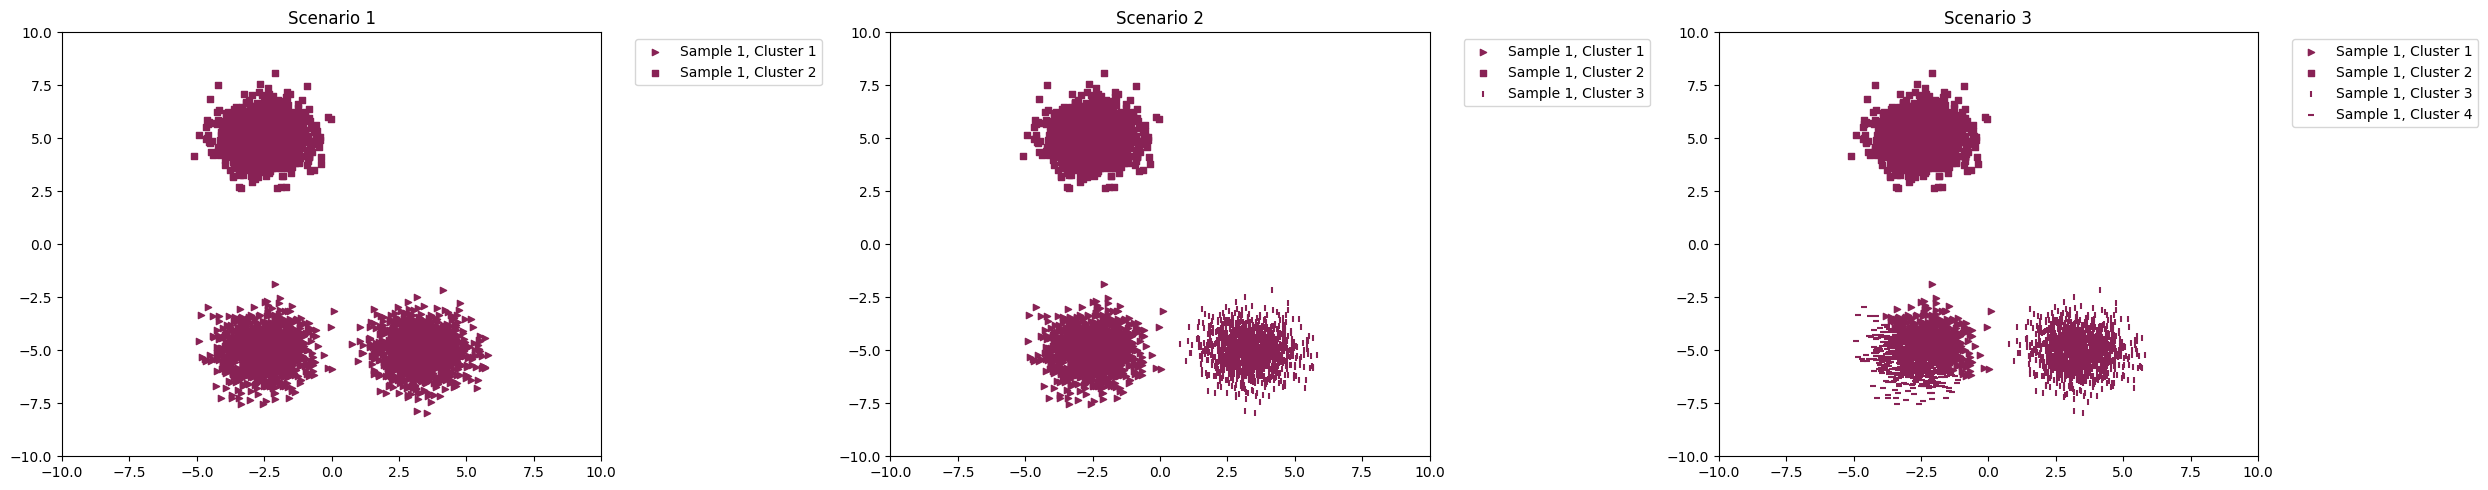

In [4]:
# Mapping dictionaries
group_to_sample = {0: 'Sample 1', 1: 'Sample 1', 2: 'Sample 1', 3: 'Sample 1'}
group_to_cell_type = {0: 'Cluster 1', 1: 'Cluster 2', 2: 'Cluster 3', 3: 'Cluster 4'}

# Generate scenarios
scenarios = []
vertical_offset = 5.0


for k in [2,3,4]:
    # Centers with increasing vertical distance
    centers = [
        [-vertical_offset/2, vertical_offset], [-vertical_offset/2, -vertical_offset],    
        [vertical_offset/1.5, -vertical_offset],    
    ]
    X, y = make_blobs(n_samples=4000, centers=centers, cluster_std=0.8, random_state=42)

    kmeans = KMeans(n_clusters=k, random_state=42)
    y = kmeans.fit_predict(X)
    scenarios.append((X, y))

# Create dataframes
scenario_names = ['k2', 'k3', 'k4']

for i, (X, y) in enumerate(scenarios):
    df = pd.DataFrame({
        'X': X[:, 0],
        'Y': X[:, 1],
        'group': y,
        'sample': [group_to_sample[g] for g in y],
        'cell_type': [group_to_cell_type[g] for g in y]
    })
    df.to_csv('./../../data/simulated_2d/original_{}.csv'.format(scenario_names[i]))


# Plot all scenarios
plot_blobs(scenarios, group_to_sample, group_to_cell_type)


In [5]:
# Demonstration of issues with nested batch effects for Batch ASW (cell type) and Batch ASW (global)
# Single cell type

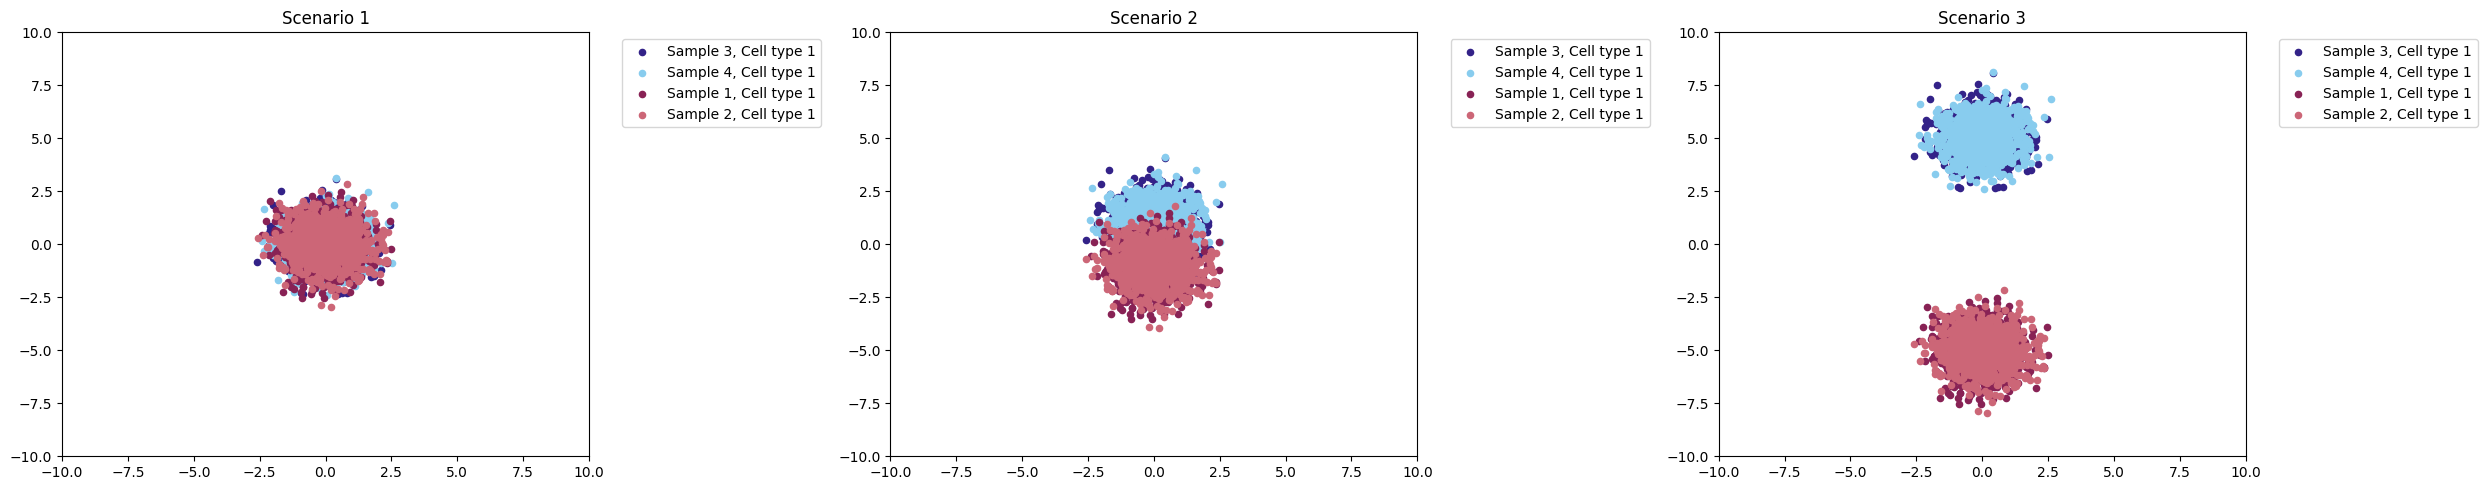

In [14]:
# Mapping dictionaries
group_to_sample = {0: 'Sample 3', 1: 'Sample 4', 2: 'Sample 1', 3: 'Sample 2'}
group_to_cell_type = {0: 'Cell type 1', 1: 'Cell type 1', 2: 'Cell type 1', 3: 'Cell type 1'}

# Generate scenarios
scenarios = []
vertical_offsets = [1.0, 5.0]

centers = [
    [0, 0], [0, 0],  # Group 1 (Sample 1, Sample 2), Cell type 1
    [0, 0], [0, 0],  # Group 2 (Sample 3, Sample 4), Cell type 1
]

X, y = make_blobs(n_samples=4000, centers=centers, cluster_std=0.8, random_state=42)
scenarios.append((X, y))

for vertical_offset in vertical_offsets:
    # Centers with increasing vertical distance
    centers = [
        [0, vertical_offset], [0, vertical_offset],    # Group 1 (Sample 1, Sample 2), Cell type 1
        [0, -vertical_offset], [0, -vertical_offset],  # Group 2 (Sample 3, Sample 4), Cell type 1
    ]
    
    X, y = make_blobs(n_samples=4000, centers=centers, cluster_std=0.8, random_state=42)
    scenarios.append((X, y))


# Create dataframes
scenario_names = ['None', 'Mild', 'Strong']
for i, (X, y) in enumerate(scenarios):
    df = pd.DataFrame({
        'X': X[:, 0],
        'Y': X[:, 1],
        'group': y,
        'sample': [group_to_sample[g] for g in y],
        'cell_type': [group_to_cell_type[g] for g in y]
    })
    df.to_csv('./../../data/simulated_2d/batch_removal_nested_{}.csv'.format(scenario_names[i]))


# Plot all scenarios
plot_blobs(scenarios, group_to_sample, group_to_cell_type)


In [7]:
# Demonstration of issues with distances/separation for Cell type ASW

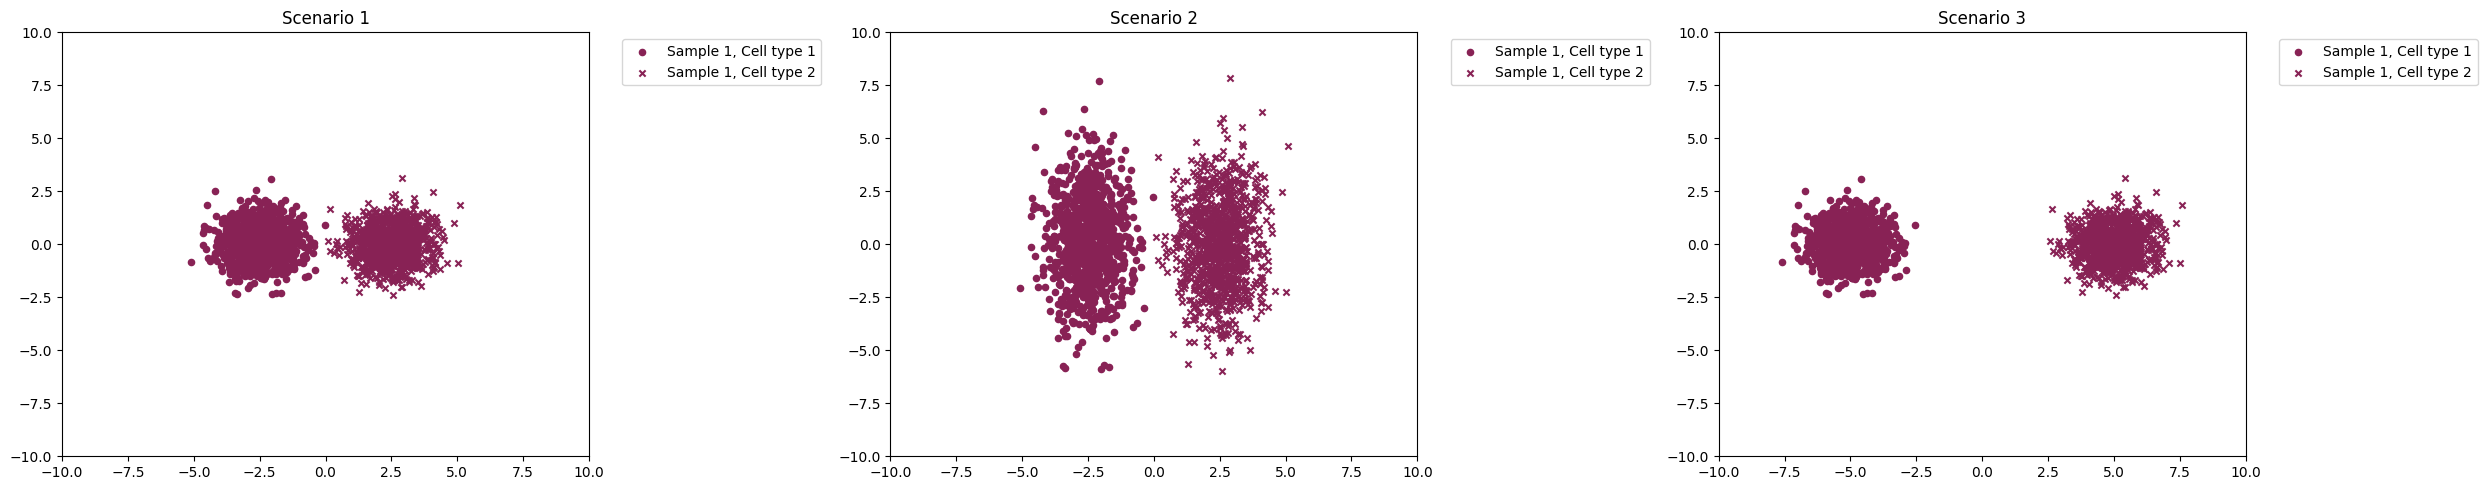

In [8]:
# Mapping dictionaries
group_to_sample = {0: 'Sample 1', 1: 'Sample 1'}
group_to_cell_type = {0: 'Cell type 1', 1: 'Cell type 2'}

# Generate scenarios
scenarios = []
horizontal_offsets = [2.5, 2.5, 5.0]

for horizontal_offset in horizontal_offsets:
    # Centers with increasing vertical distance
    centers = [
        [-horizontal_offset, 0], [horizontal_offset, 0],    # Cell type 1, Cell type 2
    ]
    X, y = make_blobs(n_samples=2000, centers=centers, cluster_std=0.8, random_state=42)
    scenarios.append((X, y))

scenarios[1][0][:, 1] *= 2.5 

# Create dataframes
scenario_names = ['good', 'worse', 'best']
for i, (X, y) in enumerate(scenarios):
    df = pd.DataFrame({
        'X': X[:, 0],
        'Y': X[:, 1],
        'group': y,
        'sample': [group_to_sample[g] for g in y],
        'cell_type': [group_to_cell_type[g] for g in y]
    })
    df.to_csv('./../../data/simulated_2d/bio_cons_distance_{}.csv'.format(scenario_names[i]))


# Plot all scenarios
plot_blobs(scenarios, group_to_sample, group_to_cell_type)

In [9]:
# Demonstration of issues with non-convex cluster shapes for Cell type ASW

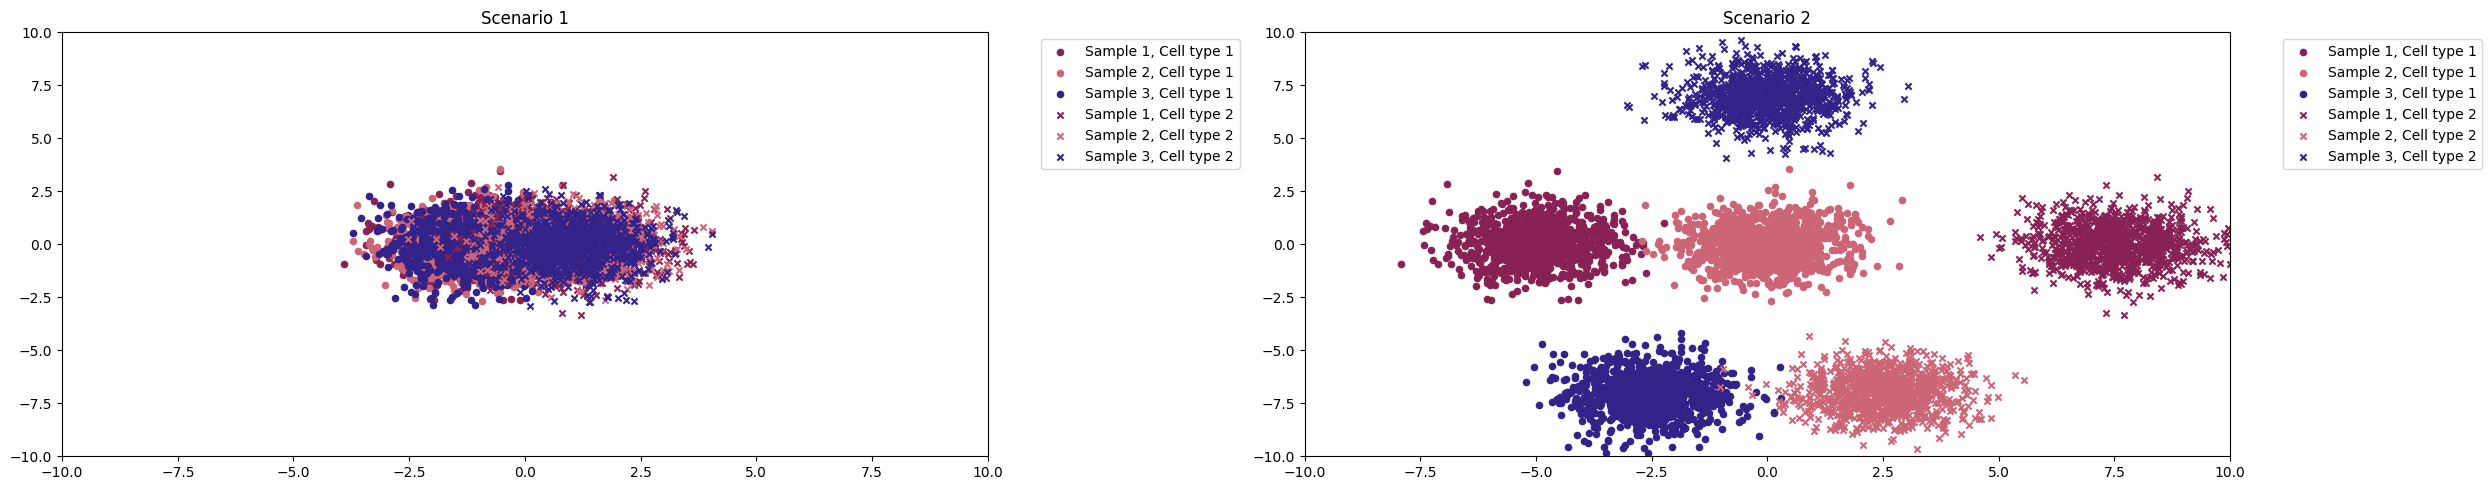

In [10]:
# Mapping dictionaries
group_to_sample = {0: 'Sample 1', 1: 'Sample 2', 2: 'Sample 3',
                   3: 'Sample 1', 4: 'Sample 2', 5: 'Sample 3'}
group_to_cell_type = {0: 'Cell type 1', 1: 'Cell type 1', 2: 'Cell type 1', 
                      3: 'Cell type 2', 4: 'Cell type 2', 5: 'Cell type 2'}

# Generate scenarios
scenarios = []
vertical_offsets = [7.0]
horizontal_offset = 5  # Constant horizontal separation


# Centers with increasing vertical distance
centers = [
    [-horizontal_offset/5, 0], [-horizontal_offset/5, 0],    # Sample 1 Cell type 1, Sample 1 Cell type 2
    [-horizontal_offset/5, 0], [horizontal_offset/5, 0],  # Sample 3 Cell type 1, Sample 1 Cell type 2
    [horizontal_offset/5, 0], [horizontal_offset/5, 0],      # Sample 2 Cell type 2, Sample 3 Cell type 2
]
    
X, y = make_blobs(n_samples=6000, centers=centers, cluster_std=0.9, random_state=42)
scenarios.append((X, y))

for vertical_offset in vertical_offsets:
    centers = [
        [-horizontal_offset, 0], [0, 0],    # Sample 1 Cell type 1, Sample 2 Cell type 1
        [-1/2*horizontal_offset, -vertical_offset],     # Sample 3 Cell type 1
        [1.5*horizontal_offset, 0],    # Sample 1 Cell type 2
        [1/2*horizontal_offset, -vertical_offset], [0, vertical_offset],    # Sample 2 Cell type 2, Sample 3 Cell type 2 
    ]
    
    X, y = make_blobs(n_samples=6000, centers=centers, cluster_std=0.9, random_state=42)
    scenarios.append((X, y))

# Create dataframes
scenario_names = ['overlap', 'batch_effects']
for i, (X, y) in enumerate(scenarios):
    df = pd.DataFrame({
        'X': X[:, 0],
        'Y': X[:, 1],
        'group': y,
        'sample': [group_to_sample[g] for g in y],
        'cell_type': [group_to_cell_type[g] for g in y]
    })
    df.to_csv('./../../data/simulated_2d/bio_cons_shape_{}.csv'.format(scenario_names[i]))


# Plot all scenarios
plot_blobs(scenarios, group_to_sample, group_to_cell_type)


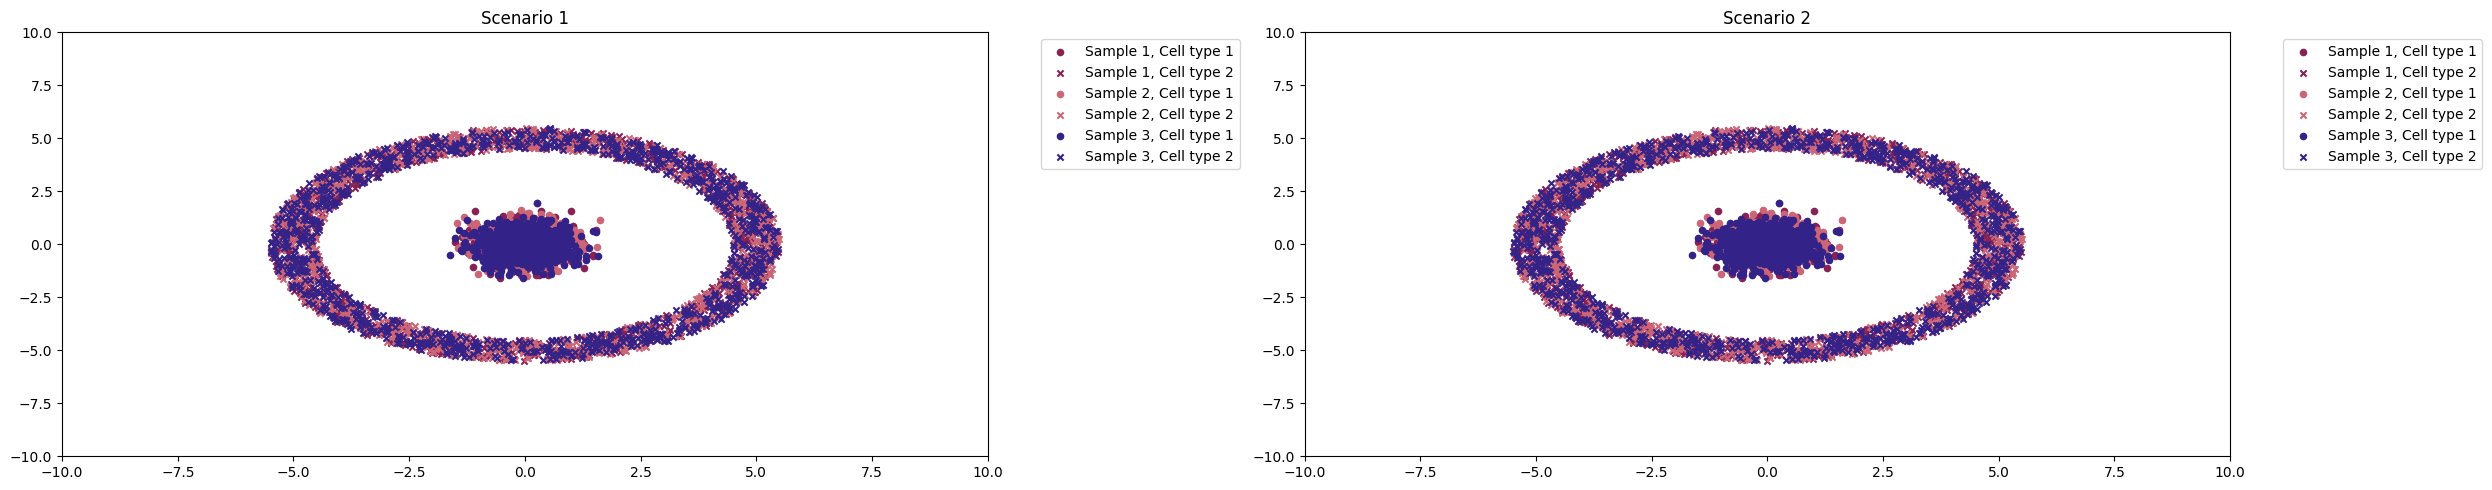

In [11]:
# Generate the central cluster
n_points_center = 3000
X_center, _ = make_blobs(n_samples=n_points_center, centers=[(0, 0)], cluster_std=0.5, random_state=42)

# Generate the ring around the central cluster
n_points_ring = 3000
radius = 4.5
width = 1

# Generate angles
angles = np.random.uniform(0, 2*np.pi, n_points_ring)

# Generate distances from center to create width
mod_radius = np.sqrt(np.random.uniform(radius**2, (radius+width)**2, n_points_ring))

# Convert polar coordinates to cartesian
X_ring = np.column_stack((mod_radius * np.cos(angles), mod_radius * np.sin(angles)))

# Combine the datasets
X = np.vstack((X_center, X_ring))

# Create a dataframe
df = pd.DataFrame(X, columns=["X", "Y"])
labels = ["Cell type 1"] * n_points_center + ["Cell type 2"] * n_points_ring
df["cell_type"] = labels
samples = ["Sample 1", "Sample 2", "Sample 3"]
n_total_points = len(X)
sample_column = [samples[i % len(samples)] for i in range(n_total_points)]
df["sample"] = sample_column

# Save to a CSV file
df.to_csv("./../../data/simulated_2d/bio_cons_shape_odd.csv", index=False)

# Plot the scenarios (twice, for not having to adapt code)

df['group'] = df['sample'] + '_' + df['cell_type']
group_to_sample = {'Sample 1_Cell type 1': 'Sample 1', 'Sample 1_Cell type 2': 'Sample 1',
                   'Sample 2_Cell type 1': 'Sample 2', 'Sample 2_Cell type 2': 'Sample 2',
                   'Sample 3_Cell type 1': 'Sample 3', 'Sample 3_Cell type 2': 'Sample 3'}

group_to_cell_type = {'Sample 1_Cell type 1': 'Cell type 1', 'Sample 1_Cell type 2': 'Cell type 2',
                   'Sample 2_Cell type 1': 'Cell type 1', 'Sample 2_Cell type 2': 'Cell type 2',
                   'Sample 3_Cell type 1': 'Cell type 1', 'Sample 3_Cell type 2': 'Cell type 2'}

X_plot = df[['X', 'Y']].values
y_plot = df['group'].values
scenarios = [(X_plot, y_plot), (X_plot, y_plot)]


plot_blobs(scenarios, group_to_sample, group_to_cell_type)


In [12]:
# Demonstration of issues with non-convex cluster shapes for Batch ASW (global)
# Two samples, three cell types

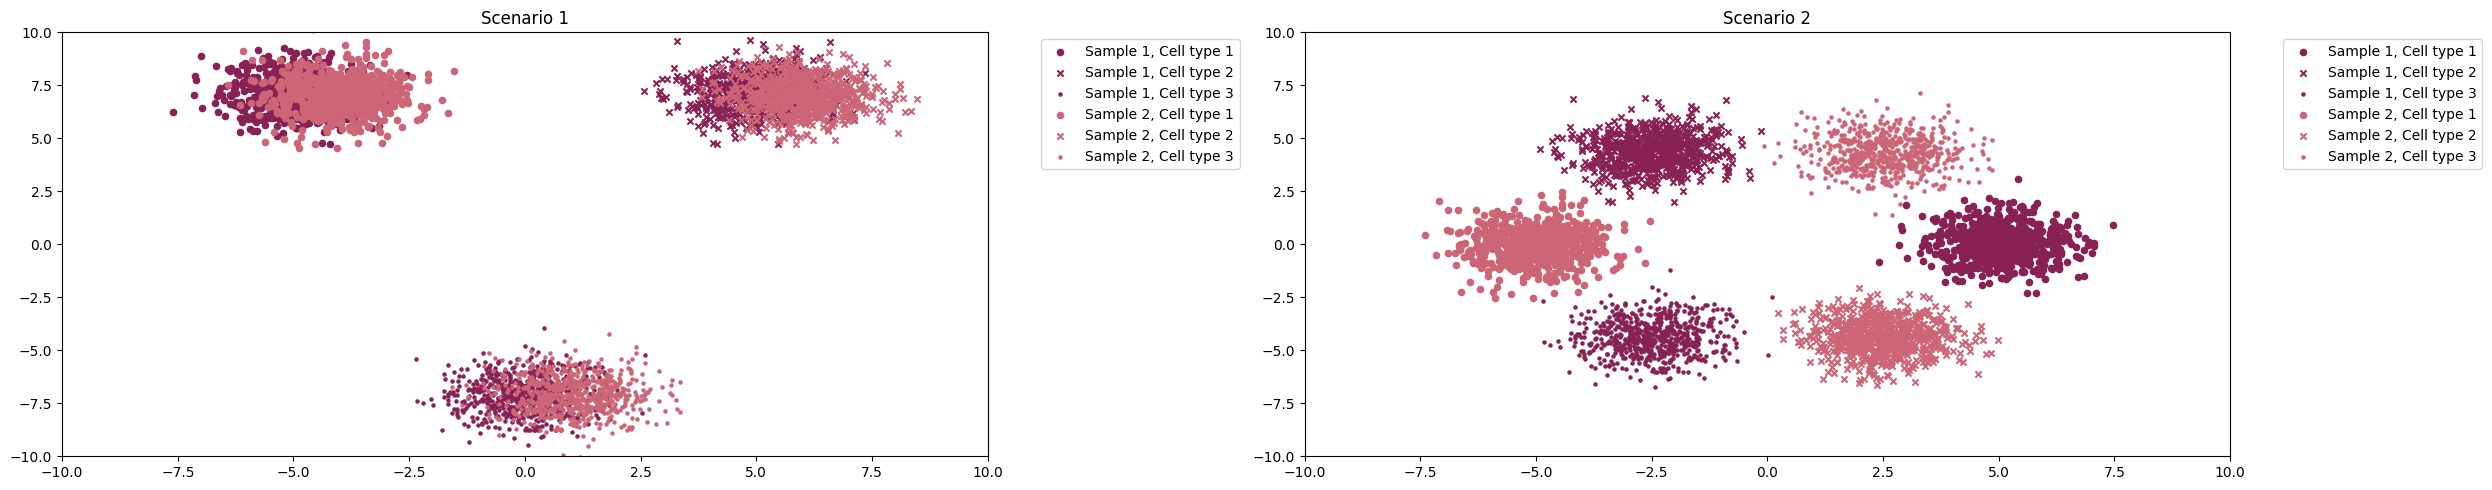

In [13]:
# Mapping dictionaries
group_to_sample = {0: 'Sample 1', 1: 'Sample 1', 2: 'Sample 1', 3: 'Sample 2', 
                   4: 'Sample 2', 5: 'Sample 2'}
group_to_cell_type = {0: 'Cell type 1', 1: 'Cell type 2', 2: 'Cell type 3', 3: 'Cell type 1', 
                      4: 'Cell type 2', 5: 'Cell type 3'}

# Generate scenarios
scenarios = []
vertical_offset = np.sqrt(5**2+5**2)
horizontal_offset = 5  # Constant horizontal separation

# Triangle shape, slight offset between samples per center
centers = [
        [-horizontal_offset, vertical_offset], [horizontal_offset, vertical_offset],    # Sample 1 (Cell type 1), Sample 1 (Cell type 2)
        [0, -vertical_offset],  # Sample 1 (Cell type 3)
        [-horizontal_offset+1, vertical_offset], [horizontal_offset+1, vertical_offset],      # Sample 2 (Cell type 1), Sample 2 (Cell type 2)
        [0+1, -vertical_offset],   # Sample 2 (Cell type 3)
    ]

X, y = make_blobs(n_samples=4000, centers=centers, cluster_std=0.8, random_state=42)
scenarios.append((X, y))


def star_pattern(n_points, radius):
    # Generate angles
    angles = np.linspace(0, 2 * np.pi, n_points, endpoint=False)
    
    # Convert polar coordinates to cartesian
    x = radius * np.cos(angles)
    y = radius * np.sin(angles)
    return list(zip(x, y))
    
radius = 5  # Adjust this value to change the size of the star

# Create star pattern for 6 points (3 cell types * 2 samples)
star_centers = star_pattern(6, radius)

# Assign centers to each group
centers = [
    star_centers[0],  # Sample 1, Cell type 1
    star_centers[2],  # Sample 2, Cell type 1
    star_centers[4],  # Sample 1, Cell type 2
    star_centers[3],  # Sample 2, Cell type 2
    star_centers[5],  # Sample 1, Cell type 3
    star_centers[1],  # Sample 2, Cell type 3
]

X, y = make_blobs(n_samples=4000, centers=centers, cluster_std=0.8, random_state=42)
scenarios.append((X, y))

# Create dataframes
scenario_names = ['None', 'Strong']
for i, (X, y) in enumerate(scenarios):
    df = pd.DataFrame({
        'X': X[:, 0],
        'Y': X[:, 1],
        'group': y,
        'sample': [group_to_sample[g] for g in y],
        'cell_type': [group_to_cell_type[g] for g in y]
    })
    df.to_csv('./../../data/simulated_2d/batch_removal_global_{}.csv'.format(scenario_names[i]))


# Plot all scenarios
plot_blobs(scenarios, group_to_sample, group_to_cell_type)
